# 52 — Pooled screening key plots (all datasets, de-leaked)

Companion to nb43 (screening benchmark) and nb49/nb50 (pooled P2Rank/patches plots). nb43 built 10 screening conditions per dataset (coach420/scpdb/holo4k/pdbbind2020) and plotted them as separate per-dataset panels. Here we **pool all four datasets into one population** (cross-dataset deduplicated, same as nb49) and draw three key plots as single panels:

1. **EF@1% vs de-leakage level** — the full ladder, one line per condition. Shown first: it's the plot that actually needs every rung, and it motivates the single-level choice the other two plots have to make.
2. **Score-threshold survival** — % of pockets with ensemble cosine score ≥ τ, τ ∈ [0, 1], at one chosen ladder level.
3. **Ground-truth rank ECDF** — fraction of pockets whose bound ligand is found by rank ≤ x, log-scale x-axis, at the same chosen level.

## New condition: Bound + Bound pocket

`CCD + Bound pocket` (nb43's `source_ccd`) already ranks the crystal pocket against the **CCD** library (49k), ground truth = the ligand's **idealised CCD conformer**. `Bound + Bound pocket` changes exactly one thing: ground truth is the **bound conformer** (the actual crystallographic pose) instead — same pocket, same CCD background. This is nb43's original `source_bound` / `screen_bound_vs_ccd` (crystal pocket, bound-conformer ground truth, ranked within the full CCD distribution), with one refinement: the ligand's own idealised-CCD row is excluded from the competing background for that pocket's ranking, so the bound pose isn't (dis)advantaged by competing against its own near-duplicate CCD self. Cached to `RESULTS/benchmark/{ds}_bound_bound_screen.parquet`.

**An earlier version of this notebook got this wrong** — it ranked the bound conformer against a much smaller *bound-conformer library* (other pockets' true poses, N = dataset size) instead of CCD, which is a different and much harder screening task by construction (see the analysis after plot 2: the two conformers actually score almost identically against the same background, so that whole apparent "21-point EF gap" was an artefact of comparing two different background libraries, not a real finding about bound vs. idealised conformers).

## What the de-leakage ladder actually is

**It's one shrinking, nested pool, not five/ten independent samples.** `L0` is the full 15,533-pocket cross-dataset-deduplicated population. Every level after that **ANDs one more condition onto the previous level's mask** — nothing is ever added back. So the sets satisfy

```
L4<0.3 ⊆ L4<0.5 ⊆ L4<0.7 ⊆ L4<0.9 ⊆ L3=0 ⊆ L3<5 ⊆ L3<25 ⊆ L3<100
      ⊆ L2<0.3 ⊆ L2<0.5 ⊆ L2<0.7 ⊆ L1 ⊆ L0
```

with equality only where a filter doesn't happen to remove anyone. A sanity check below confirms this holds in the actual data. This is deliberately the **opposite** convention from `combined_deleakage_analysis.py`'s manuscript grid, which partitions each rung into *disjoint* strata so one bin's effect isn't diluted by everything looser pooled in with it — that's the right choice when asking "does retrieval quality vary by SI% stratum", but the wrong one here: each plot below needs *one* self-consistent, maximally-de-leaked hold-out set, not a partition.

## The ladder now goes past receptor identity

`L0`/`L1` (whole pool / PDB-identity de-leaked) are nb43's original rungs. Every rung after that reuses the **exact bin edges** `ligand_frequency_analysis.py` / `ligand_similarity_analysis.py` / `combined_deleakage_analysis.py` already established for this project's own manuscript-grid strata — but applied as successive cumulative cuts on the *same* shrinking pool, not as a partition into disjoint strata (that's a different, equally valid question — "does retrieval vary by stratum" — just not this one):

* **`L2<0.7` / `L2<0.5` / `L2<0.3`** — receptor sequence identity to the nearest training receptor below 70% / 50% / 30% (`pocket_seq_identity.tsv`).
* **`L3<100` / `L3<25` / `L3<5` / `L3=0`** — within `L2<0.3` (novel receptor), the bound ligand's CCD code appeared in training in fewer than 100 / 25 / 5 / **0** distinct training complexes (`train_ligand_freq`). `L3=0` means this *exact chemical entity* was never bound to anything during training.
* **`L4<0.9` / `L4<0.7` / `L4<0.5` / `L4<0.3`** — within `L3=0`, the ligand's nearest ECFP4 (Morgan, radius 2, 2048-bit) Tanimoto similarity to *any* training ligand is below 0.9 / 0.7 / 0.5 / 0.3 — i.e. even a structurally-similar training ligand isn't there. `L4<0.3` is the strictest "novel scaffold" cut.

In [61]:
from __future__ import annotations

import json
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from rdkit.DataStructs import BulkTanimotoSimilarity
RDLogger.DisableLog('rdApp.*')

PROJ    = Path.cwd().parent / 'DATA' / 'drugclip'
BENCH   = PROJ / 'RESULTS' / 'benchmark'
NL_ROOT = Path.cwd().parent / 'DATA' / 'natural_ligands'
sys.path.insert(0, str(Path.cwd() / 'natural_ligands_scripts'))
import screening as sc
from ligand_frequency_analysis import train_ligand_freq

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.labelsize': 13, 'xtick.labelsize': 13,
                     'ytick.labelsize': 13})

SHOW_TITLES_LEGENDS = False  # flip to True to bring back titles + legends on plots 1-3

ds_order = ['coach420', 'scpdb', 'holo4k', 'pdbbind2020']
DATASET_PRIORITY = ['coach420', 'scpdb', 'pdbbind2020', 'holo4k']  # nb49 order

## Condition registry

Same 9 CCD-library conditions as nb43 (colours/labels carried over unchanged for continuity with every other pooled plot in this project), plus the new `bound_bound` condition (green — the same colour nb43 used for `source_bound`, since both are the "ceiling" bound-pose condition).

In [50]:
CONDITIONS = [
    ('bound_bound',               '#2CA02C', 'Bound + Bound pocket'),
    ('source_ccd',                '#17BECF', 'CCD + Bound pocket'),
    ('holo_ccd',                  '#FF7F0E', 'CCD + Holo pocket'),
    ('apo_ccd',                   '#1F77B4', 'CCD + Apo pocket'),
    ('afdb_translated_ccd',       '#9467BD', 'CCD + AFDB-translated'),
    ('afdb_p2rank_correct_ccd',   '#D62728', 'CCD + AFDB P2Rank ✓'),
    ('pdb_p2rank_correct_ccd',    '#E377C2', 'CCD + PDB P2Rank ✓'),
    ('afdb_p2rank_wrong_ccd',     '#7F7F7F', 'CCD + AFDB P2Rank ✗'),
    ('pdb_p2rank_wrong_ccd',      '#8C564B', 'CCD + PDB P2Rank ✗'),
    ('patches_ccd',               '#000000', 'CCD + Patches'),
]
COND_IDS    = [c[0] for c in CONDITIONS]
COND_COLOUR = {c[0]: c[1] for c in CONDITIONS}
COND_LABEL  = {c[0]: c[2] for c in CONDITIONS}
CCD_CONDS   = [c for c in COND_IDS if c != 'bound_bound']

## Load the 9 CCD-library conditions (nb43 cache, no recomputation)

In [51]:
raw: dict[str, pd.DataFrame] = {}
for cond in CCD_CONDS:
    frames = [pd.read_parquet(BENCH / f'{ds}_{cond}_screen.parquet') for ds in ds_order]
    raw[cond] = pd.concat(frames, ignore_index=True)
    print(f'{cond:28s} raw n={len(raw[cond]):,}')

source_ccd                   raw n=17,305
holo_ccd                     raw n=17,305
apo_ccd                      raw n=17,305
afdb_translated_ccd          raw n=17,305
afdb_p2rank_correct_ccd      raw n=17,305
pdb_p2rank_correct_ccd       raw n=17,305
afdb_p2rank_wrong_ccd        raw n=17,305
pdb_p2rank_wrong_ccd         raw n=17,305
patches_ccd                  raw n=17,305


## Compute (or load cached) Bound + Bound pocket condition

Crystal pocket, scored against the full CCD library, ground truth = the bound conformer's ensemble score — same background nb43's `source_ccd` uses, just a different ground-truth molecule. The one addition: the ligand's own idealised-CCD row is dropped from the background count for that pocket's rank, so the bound pose never competes against its own near-duplicate.

In [4]:
ccd_lib = sc.load_mol_library('CCD')
N_CCD = ccd_lib.emb.shape[0]
ccd_id2row: dict[str, int] = {}
for i, mid in enumerate(ccd_lib.ids):
    ccd_id2row.setdefault(str(mid), i)
print(f'N_CCD = {N_CCD:,}')

cache_paths = {ds: BENCH / f'{ds}_bound_bound_screen.parquet' for ds in ds_order}
if all(p.exists() for p in cache_paths.values()):
    frames = [pd.read_parquet(cache_paths[ds]) for ds in ds_order]
    bound_bound_df = pd.concat(frames, ignore_index=True)
    print(f'Bound + Bound pocket: loaded from cache, n={len(bound_bound_df):,}')
else:
    t0 = time.time()
    frames = []
    for ds in ds_order:
        ps = sc.load_pocket_set(ds)
        bound_lib = sc.load_mol_library(f'bound_{ds}')
        bound_id2row: dict[str, int] = {}
        for i, mid in enumerate(bound_lib.ids):
            bound_id2row.setdefault(str(mid), i)

        P = len(ps.names)
        sims = sc.ensemble_scores(ps, ccd_lib, np.arange(P))  # (P, N_CCD)
        pdb_id_arr = ps.manifest['pdb_id'].to_numpy(dtype=object)

        rows = []
        for i, pid in enumerate(ps.names):
            lig = ps.lig_resname[i]
            brow = bound_id2row.get(pid)
            rec = {'pocket_id': pid, 'lig_resname': lig, 'pdb_id': pdb_id_arr[i],
                   'valid': True, 'condition': 'bound_bound', 'dataset': ds}
            if brow is None:
                rec.update(in_library=False, gt_score=pd.NA, gt_rank=pd.NA)
            else:
                gs = float(sum(ps.emb[k, i, :] @ bound_lib.emb[brow, k, :]
                              for k in range(6)) / 6)
                own_row = ccd_id2row.get(str(lig))
                srow = sims[i]
                beaten = int((srow > gs).sum())
                if own_row is not None and srow[own_row] > gs:
                    beaten -= 1  # own idealised-CCD row excluded from the background
                rec.update(in_library=True, gt_score=gs, gt_rank=beaten + 1)
            rows.append(rec)
        pp = pd.DataFrame(rows)
        pp.to_parquet(cache_paths[ds], index=False)
        frames.append(pp)

        ev = pp[pp['in_library']]
        pct_k = max(1, round(0.01 * N_CCD))
        ef = ((ev['gt_rank'] <= pct_k).mean() * N_CCD / pct_k
              if len(ev) else float('nan'))
        print(f'{ds:12s} bound_bound  P={P:,}  in_library={len(ev):,}  ef@1%~{ef:.1f}')
    bound_bound_df = pd.concat(frames, ignore_index=True)
    print(f'Total wall time: {time.time() - t0:.1f}s')

raw['bound_bound'] = bound_bound_df

N_CCD = 48,999
Bound + Bound pocket: loaded from cache, n=17,305


## Cross-dataset dedup + per-row library size

`dedup_cross_dataset` — identical logic to nb49 / `combined_deleakage_analysis.dedup_cross_dataset`: for a (pdb_id, lig_resname) pair spanning more than one dataset, keep only the row from the first dataset in `DATASET_PRIORITY`. Applied to every condition's own raw frame (all conditions share the same underlying pocket rows, so the same pockets survive in every condition).

Every condition now shares the same CCD-sized background, so `n_lib` is just `N_CCD` throughout (kept as an explicit per-row column rather than a bare constant only so the EF-pooling formula below stays general).

In [5]:
def dedup_cross_dataset(pp: pd.DataFrame,
                        priority: list[str] = DATASET_PRIORITY) -> pd.DataFrame:
    key = pd.Series(list(zip(pp['pdb_id'].str.lower().str.strip(),
                              pp['lig_resname'].str.upper())), index=pp.index)
    winner = pp.groupby(key)['dataset'].transform(
        lambda s: next(d for d in priority if d in set(s)))
    return pp[pp['dataset'] == winner].copy()


pooled: dict[str, pd.DataFrame] = {}
for cond in COND_IDS:
    df = dedup_cross_dataset(raw[cond])
    df['n_lib'] = N_CCD
    df['pct_k'] = np.maximum(1, np.round(0.01 * df['n_lib'])).astype(int)
    pooled[cond] = df
    ev = df['valid'] & df['in_library']
    print(f'{COND_LABEL[cond]:24s} deduped n={len(df):,}   '
          f'valid&in_library n={int(ev.sum()):,}')

Bound + Bound pocket     deduped n=15,640   valid&in_library n=15,640


CCD + Bound pocket       deduped n=15,640   valid&in_library n=15,533


CCD + Holo pocket        deduped n=15,640   valid&in_library n=10,718


CCD + Apo pocket         deduped n=15,640   valid&in_library n=6,867


CCD + AFDB-translated    deduped n=15,640   valid&in_library n=12,930


CCD + AFDB P2Rank ✓      deduped n=15,640   valid&in_library n=8,233


CCD + PDB P2Rank ✓       deduped n=15,640   valid&in_library n=13,327


CCD + AFDB P2Rank ✗      deduped n=15,640   valid&in_library n=8,299


CCD + PDB P2Rank ✗       deduped n=15,640   valid&in_library n=14,542


CCD + Patches            deduped n=15,640   valid&in_library n=15,533


## De-leakage level masks

`L0`/`L1`/`L2<t` — PDB-identity and receptor-SI%-to-training, exactly nb43's ladder. `L3<t` / `L3=0` / `L4<t` — new, built inside `L2<0.3`, using ligand training-frequency (`train_ligand_freq`) and nearest-training-ligand ECFP4 Tanimoto. Fingerprints are computed once, only for the CCD codes actually in play (this pool's ligands ∪ the training ligand vocabulary) rather than the full 49k-compound CCD — a few thousand molecules, seconds not minutes.

In [53]:
TRAIN_JSON = NL_ROOT / 'DATA' / 'DRUGCLIP_BIOLIP_TRAINING.json'
SEQ_ID_TSV = NL_ROOT / 'RESULTS' / 'deleakage' / 'pocket_seq_identity.tsv'
CCD_MANIFEST = NL_ROOT / 'RESULTS' / 'components_pub_unimol_manifest.tsv'

folds = json.loads(TRAIN_JSON.read_text())
training_union: set[str] = {x.lower().strip() for v in folds.values() for x in v}

seq_df = pd.read_csv(SEQ_ID_TSV, sep='\t')
pocket_best_pident = dict(zip(seq_df['pocket'], seq_df['best_pident']))

LIG_FREQ = train_ligand_freq().set_index('ligand')['n_pdbs'].to_dict()

# --- nearest-training-ligand Tanimoto (ECFP4/Morgan r=2, 2048 bit) ---
eval_codes: set[str] = set()
for df in pooled.values():
    ev = df[df['valid'] & df['in_library']]
    eval_codes |= set(ev['lig_resname'].str.upper().dropna())
train_codes = {c.upper() for c in LIG_FREQ}
need_codes  = eval_codes | train_codes

man = pd.read_csv(CCD_MANIFEST, sep='\t', dtype=str)
man = man[man['identifier'].str.upper().isin(need_codes)]
fp_map: dict[str, object] = {}
for code_, smi in zip(man['identifier'], man['smiles']):
    if not isinstance(smi, str) or not smi:
        continue
    m = Chem.MolFromSmiles(smi)
    if m is not None:
        fp_map[str(code_).upper()] = AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)

train_fps = [fp_map[c] for c in train_codes if c in fp_map]
t0 = time.time()
NN_TS: dict[str, float] = {}
for c in eval_codes:
    if c not in fp_map:
        continue
    sims = BulkTanimotoSimilarity(fp_map[c], train_fps)
    NN_TS[c] = max(sims) if sims else 0.0
print(f'nearest-training-ligand Tanimoto: {len(NN_TS):,} eval ligand codes '
      f'({len(train_fps):,} training fps) in {time.time() - t0:.1f}s')

DE_LEVELS = ['L0', 'L1', 'L2<0.7', 'L2<0.5', 'L2<0.3',
             'L3<100', 'L3<25', 'L3<5', 'L3=0',
             'L4<0.9', 'L4<0.7', 'L4<0.5', 'L4<0.3']


def format_level_label(level: str) -> str:
    """'L2<0.7' -> 'L$_2$ < 0.7'; 'L3=0' -> 'L$_3$ = 0'; 'L0' -> 'L$_0$' — stage
    number subscripted, a space added either side of the comparison operator."""
    m = re.match(r'L(\d)(<|=)?(.*)', level)
    stage, op, rest = m.group(1), m.group(2), m.group(3)
    label = f'L$_{{{stage}}}$'
    if op:
        label += f' {op} {rest}'
    return label


DE_LEVELS_FMT = [format_level_label(lv) for lv in DE_LEVELS]


def get_level_mask(df: pd.DataFrame, level: str) -> np.ndarray:
    mask = np.ones(len(df), dtype=bool)
    if level == 'L0':
        return mask
    in_train = df['pdb_id'].str.lower().str.strip().isin(training_union).to_numpy()
    mask &= ~in_train
    if level == 'L1':
        return mask
    bid = df['pocket_id'].map(pocket_best_pident).fillna(0.0).to_numpy()
    if level.startswith('L2<'):
        mask &= (bid < float(level.split('<')[1]))
        return mask
    mask &= (bid < 0.3)  # every L3/L4 rung lives inside L2<0.3
    lig_freq = df['lig_resname'].str.upper().map(LIG_FREQ).fillna(0).astype(int).to_numpy()
    if level.startswith('L3<'):
        mask &= (lig_freq < float(level.split('<')[1]))
        return mask
    mask &= (lig_freq == 0)
    if level == 'L3=0':
        return mask
    # L4<t: unseen ligand codes (no fingerprint) can't be shown novel -> excluded
    nn_ts = df['lig_resname'].str.upper().map(NN_TS).fillna(1.0).to_numpy()
    mask &= (nn_ts < float(level.split('<')[1]))
    return mask

nearest-training-ligand Tanimoto: 5,928 eval ligand codes (22,774 training fps) in 30.3s


### Sanity check: is this really nested?

In [7]:
check_df = pooled['source_ccd']
check_ev = (check_df['valid'] & check_df['in_library']).to_numpy()
prev = None
for lv in DE_LEVELS:
    cur = get_level_mask(check_df, lv) & check_ev
    if prev is not None:
        assert np.all(cur <= prev), f'{lv} is NOT a subset of the previous level!'
    prev = cur
print('OK — every level is a strict subset of the one before it '
      "(checked on 'CCD + Bound pocket').")

OK — every level is a strict subset of the one before it (checked on 'CCD + Bound pocket').


## De-leakage ladder: how the pool shrinks, every condition

The full trade-off, all ten conditions × all ten levels. This is what plot 1 below sweeps in one line per condition; it's also the table that has to justify whichever single level plots 2/3 pick.

In [8]:
level_counts = pd.DataFrame({
    COND_LABEL[cond]: {
        level: int((get_level_mask(pooled[cond], level)
                    & pooled[cond]['valid'].to_numpy()
                    & pooled[cond]['in_library'].to_numpy()).sum())
        for level in DE_LEVELS
    }
    for cond in COND_IDS
}).T.reindex([COND_LABEL[c] for c in COND_IDS])
level_counts

,L0,L1,L2<0.7,L2<0.5,L2<0.3,L3<100,L3<25,L3<5,L3=0,L4<0.9,L4<0.7,L4<0.5,L4<0.3
Bound + Bound pocket,15640,9412,2728,1925,961,628,540,425,286,241,223,136,9
CCD + Bound pocket,15533,9323,2705,1908,958,625,537,423,284,241,223,136,9
CCD + Holo pocket,10718,6531,1658,1125,525,383,336,272,191,172,162,105,8
CCD + Apo pocket,6867,3458,567,403,194,125,111,75,51,40,37,14,2
CCD + AFDB-translated,12930,7828,2235,1557,731,504,437,344,244,205,191,121,8
CCD + AFDB P2Rank ✓,8233,4807,1402,999,412,292,258,219,164,139,131,92,7
CCD + PDB P2Rank ✓,13327,7866,2313,1618,811,522,451,365,244,211,197,124,9
CCD + AFDB P2Rank ✗,8299,4800,1381,974,418,305,267,226,167,141,133,94,6
CCD + PDB P2Rank ✗,14542,8846,2633,1851,937,609,524,412,275,236,218,134,7
CCD + Patches,15533,9323,2705,1908,958,625,537,423,284,241,223,136,9


## Plot 1 — EF@1% vs de-leakage level (pooled)

One pooled population per level (not per dataset). EF is pooled as **total hits / total expected-random-hits** (`Σ hit / Σ pct_k/n_lib`) rather than a naive average of per-pocket rates — this is equivalent to the ordinary EF formula since every condition now shares the same CCD-sized background (`n_lib` constant), and stays correct as a general pooling rule if that ever changes again.

Past `L2<0.3` several conditions get thin (see the table above — `L4<0.3` is single digits everywhere). Rather than just saying so in prose, **each line switches from solid to dashed right after its last level with ≥100 pooled pockets** — the dashed tail is exactly the part of the curve that's noisy, visually, per condition (a weak condition like `apo_ccd` goes dashed much earlier than `patches_ccd`).

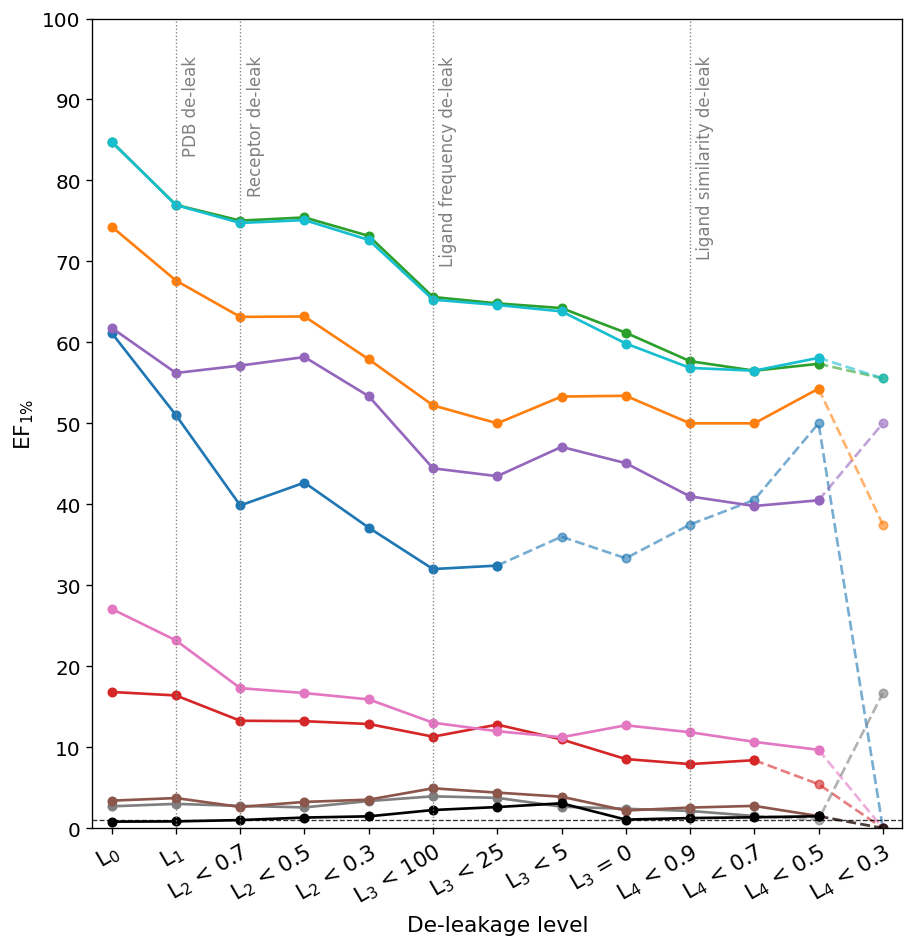


—— EF@1% by level (pooled) ——


level,L0,L1,L2<0.7,L2<0.5,L2<0.3,L3<100,L3<25,L3<5,L3=0,L4<0.9,L4<0.7,L4<0.5,L4<0.3
condition,,,,,,,,,,,,,
Bound + Bound pocket,84.8,77.0,75.0,75.4,73.2,65.6,64.8,64.2,61.2,57.7,56.5,57.4,55.6
CCD + Bound pocket,84.8,77.0,74.7,75.1,72.6,65.3,64.6,63.8,59.9,56.8,56.5,58.1,55.6
CCD + Holo pocket,74.3,67.6,63.1,63.2,57.9,52.2,50.0,53.3,53.4,50.0,50.0,54.3,37.5
CCD + Apo pocket,61.2,51.0,39.9,42.7,37.1,32.0,32.4,36.0,33.3,37.5,40.5,50.0,0.0
CCD + AFDB-translated,61.8,56.2,57.1,58.2,53.4,44.4,43.5,47.1,45.1,41.0,39.8,40.5,50.0
CCD + AFDB P2Rank ✓,16.8,16.4,13.3,13.2,12.9,11.3,12.8,11.0,8.5,7.9,8.4,5.4,0.0
CCD + PDB P2Rank ✓,27.1,23.2,17.3,16.7,15.9,13.0,12.0,11.2,12.7,11.8,10.7,9.7,0.0
CCD + AFDB P2Rank ✗,2.7,3.0,2.8,2.6,3.3,3.9,3.7,2.7,2.4,2.1,1.5,1.1,16.7
CCD + PDB P2Rank ✗,3.4,3.7,2.6,3.2,3.5,4.9,4.4,3.9,2.2,2.5,2.8,1.5,0.0


In [60]:
def pooled_ef1pct(df: pd.DataFrame, level: str) -> tuple[float, int]:
    ev = df[get_level_mask(df, level) & df['valid'] & df['in_library']].copy()
    if len(ev) == 0:
        return float('nan'), 0
    ev['hit'] = (ev['gt_rank'] <= ev['pct_k']).astype(float)
    frac = ev['pct_k'] / ev['n_lib']
    ef = ev['hit'].sum() / frac.sum()
    return ef, len(ev)


ef_rows = []
for cond in COND_IDS:
    for level in DE_LEVELS:
        ef, n = pooled_ef1pct(pooled[cond], level)
        ef_rows.append({'condition': cond, 'level': level, 'ef@1%': ef, 'n': n})
ef_summary = pd.DataFrame(ef_rows)

MIN_RELIABLE_N = 100

fig, ax = plt.subplots(figsize=(8, 8))
x_all = np.arange(len(DE_LEVELS))
for cond in COND_IDS:
    sub = ef_summary[ef_summary['condition'] == cond].set_index('level').reindex(DE_LEVELS)
    y, n = sub['ef@1%'].to_numpy(), sub['n'].to_numpy()
    reliable = np.where(n >= MIN_RELIABLE_N)[0]
    k = reliable.max() if len(reliable) else 0
    color = COND_COLOUR[cond]
    ax.plot(x_all[:k + 1], y[:k + 1], marker='o', ms=5, lw=1.6,
            color=color, label=COND_LABEL[cond])
    ax.plot(x_all[k:], y[k:], marker='o', ms=5, lw=1.6, ls='--',
            color=color, alpha=0.6)
ax.set_xticks(x_all)
ax.set_xticklabels(DE_LEVELS_FMT, rotation=30, ha='right',
                   rotation_mode='anchor', fontsize=13)
ax.set_xlim(x_all[0] - 0.3, x_all[-1] + 0.3)
ax.set_yticks(range(0, 101, 10)); ax.set_ylim(0, 100)
# vertical markers sit ON the level where each de-leak stage begins, not between points.
# 6 trailing spaces push the visible word down, off the top axis border (rotation=90 +
# va='top' reads bottom-to-top, so trailing chars land nearest the border).
for xpos, txt in [(DE_LEVELS.index('L1'), 'PDB de-leak       '),
                  (DE_LEVELS.index('L2<0.7'), 'Receptor de-leak       '),
                  (DE_LEVELS.index('L3<100'), 'Ligand frequency de-leak       '),
                  (DE_LEVELS.index('L4<0.9'), 'Ligand similarity de-leak       ')]:
    ax.axvline(xpos, color='grey', lw=0.8, ls=':')
    ax.annotate(txt, (xpos + 0.1, ax.get_ylim()[1]), fontsize=10, color='grey',
                rotation=90, va='top', ha='left')
ax.axhline(1.0, ls='--', lw=0.8, color='black', alpha=0.8)
ax.set_ylabel(r'EF$_{1\%}$', fontsize=13); ax.set_xlabel('De-leakage level', fontsize=13)
if SHOW_TITLES_LEGENDS:
    ax.set_title(r'Pooled EF$_{1\%}$ vs de-leakage level (all datasets, de-duplicated)')
    # Legend sits outside the axes so it never covers the 'Ligand similarity de-leak' marker
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_box_aspect(1)
fig.tight_layout()
fig.savefig(BENCH / 'fig52_ef1pct_vs_deleak_pooled.png', dpi=600, bbox_inches='tight')
plt.show()

print(f'\n—— EF@1% by level (pooled) ——')
display(ef_summary.pivot(index='condition', columns='level', values='ef@1%')
        .reindex(COND_IDS).reindex(columns=DE_LEVELS).round(1)
        .rename(index=COND_LABEL))

## Choosing the de-leak level for plots 2 & 3

Plot 1 sweeps the whole ladder, so it needs no single choice. Plots 2 and 3 draw one curve per condition and can't show ten levels at once, so **one** level has to be picked — see the shrinkage table above. `L0` is exactly the number the task says not to use uncritically (some pockets' PDB entries were literally in training). `L3=0`/`L4<*` de-leak hardest but the weakest condition (`apo_ccd`) is down to 51 pockets at `L3=0` and 2 at `L4<0.3` — too thin for a stable histogram or ECDF; even the strongest conditions are only ~130 pockets at `L4<0.5` and single digits at `L4<0.3`.

**Decision: `L3<25`** — receptor de-leaked (`L2<0.3`, SI<30% to nearest training receptor) *and* the bound ligand's CCD code was seen fewer than 25 times in training. This is a deliberately stricter cut than `L1`: it de-leaks both the protein *and* the ligand side (a receptor-novel pocket whose ligand is ATP is still "seen chemistry"), while stopping well short of `L3=0`/`L4<*`, which shrink the weakest condition (`apo_ccd`) to 51/14/2 pockets. At `L3<25`, every condition keeps **at least 111 pockets** (`apo_ccd`; every other condition is 258–540) — thin enough that the tail of a plot should be read qualitatively, but not so thin the curve is meaningless.

In [10]:
PLOT_LEVEL = 'L3<25'

## Plot 2 — Score-threshold survival (pooled, L3<25)

% of de-leaked, in-library pockets whose ensemble cosine score is ≥ τ, for τ swept 0 → 1.

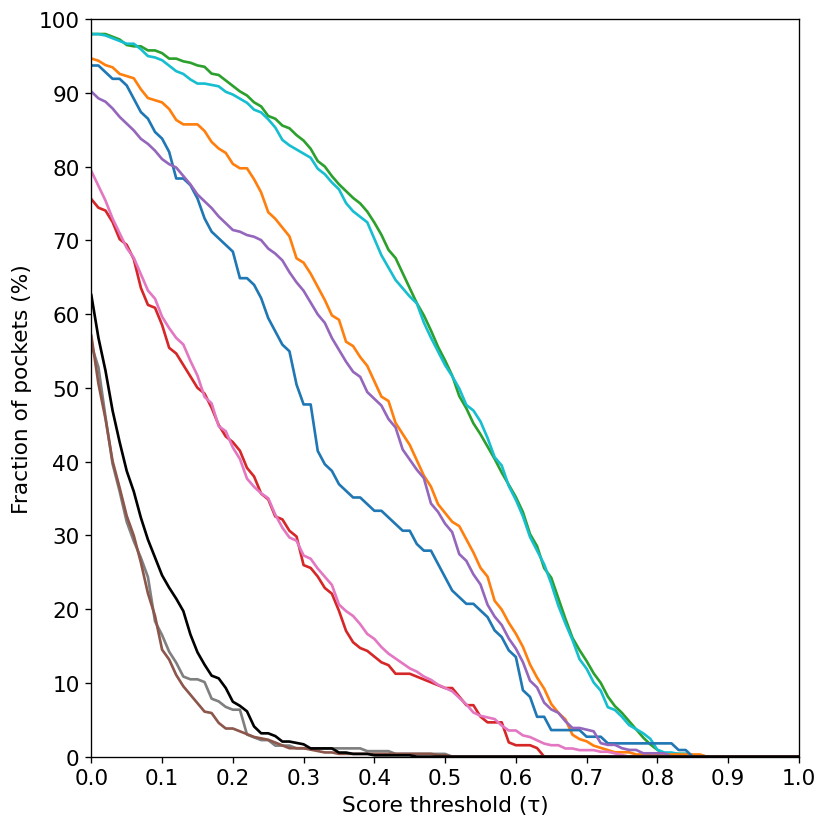

In [62]:
thresholds = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(7, 7))
for cond in COND_IDS:
    df  = pooled[cond]
    ev  = df[get_level_mask(df, PLOT_LEVEL) & df['valid'] & df['in_library']]
    vals = ev['gt_score'].dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        continue
    surv = np.array([(vals >= t).mean() * 100 for t in thresholds])
    ax.plot(thresholds, surv, color=COND_COLOUR[cond], lw=1.6,
            label=f'{COND_LABEL[cond]} (n={len(vals):,})')
ax.set_xlim(0, 1); ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 1.01, 0.1)); ax.set_yticks(range(0, 101, 10))
ax.set_xlabel('Score threshold (τ)'); ax.set_ylabel('Fraction of pockets (%)')
if SHOW_TITLES_LEGENDS:
    ax.set_title(f'Pooled, de-duplicated, {PLOT_LEVEL} — score-threshold survival')
    ax.legend(fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig(BENCH / 'fig52_score_survival_pooled.png', dpi=600, bbox_inches='tight')
plt.show()

### Does the true bound pose score better or worse than the idealised CCD conformer of the same molecule?

Now that `Bound + Bound pocket` and `CCD + Bound pocket` share the same background, this is the actual question the pairing answers — and the two curves above are nearly on top of each other because the answer is **"barely any difference, in either direction"**: essentially a coin flip which conformer scores higher for a given pocket, with a negligible average gap. The pocket encoder isn't picky about idealised vs. binding-distorted geometry for this ligand.

In [12]:
_ccd = pooled['source_ccd'][pooled['source_ccd']['valid'] & pooled['source_ccd']['in_library']]
_bb  = pooled['bound_bound'][pooled['bound_bound']['valid'] & pooled['bound_bound']['in_library']]
_m = (_ccd[['pocket_id', 'dataset', 'gt_score']]
      .merge(_bb[['pocket_id', 'dataset', 'gt_score']],
             on=['pocket_id', 'dataset'], suffixes=('_ccd_conformer', '_bound_conformer')))

print(f'pockets with both conformers scored: {len(_m):,}')
print(f"score correlation (Pearson): {_m['gt_score_ccd_conformer'].corr(_m['gt_score_bound_conformer']):.3f}")
print(f"mean score   — idealised CCD conformer: {_m['gt_score_ccd_conformer'].mean():.3f}   "
      f"bound conformer: {_m['gt_score_bound_conformer'].mean():.3f}")
print(f"median score — idealised CCD conformer: {_m['gt_score_ccd_conformer'].median():.3f}   "
      f"bound conformer: {_m['gt_score_bound_conformer'].median():.3f}")
frac_ccd_higher = (_m['gt_score_ccd_conformer'] > _m['gt_score_bound_conformer']).mean()
print(f"fraction of pockets where the idealised CCD conformer outscores the bound "
      f"conformer: {frac_ccd_higher*100:.1f}%")

pockets with both conformers scored: 15,533
score correlation (Pearson): 0.929
mean score   — idealised CCD conformer: 0.647   bound conformer: 0.645
median score — idealised CCD conformer: 0.720   bound conformer: 0.713
fraction of pockets where the idealised CCD conformer outscores the bound conformer: 53.7%


## Plot 3 — Ground-truth rank ECDF (pooled, L3<25)

Log-scale ECDF of `gt_rank`. All 10 conditions now share the same CCD-sized background, so rank is on one consistent scale throughout.

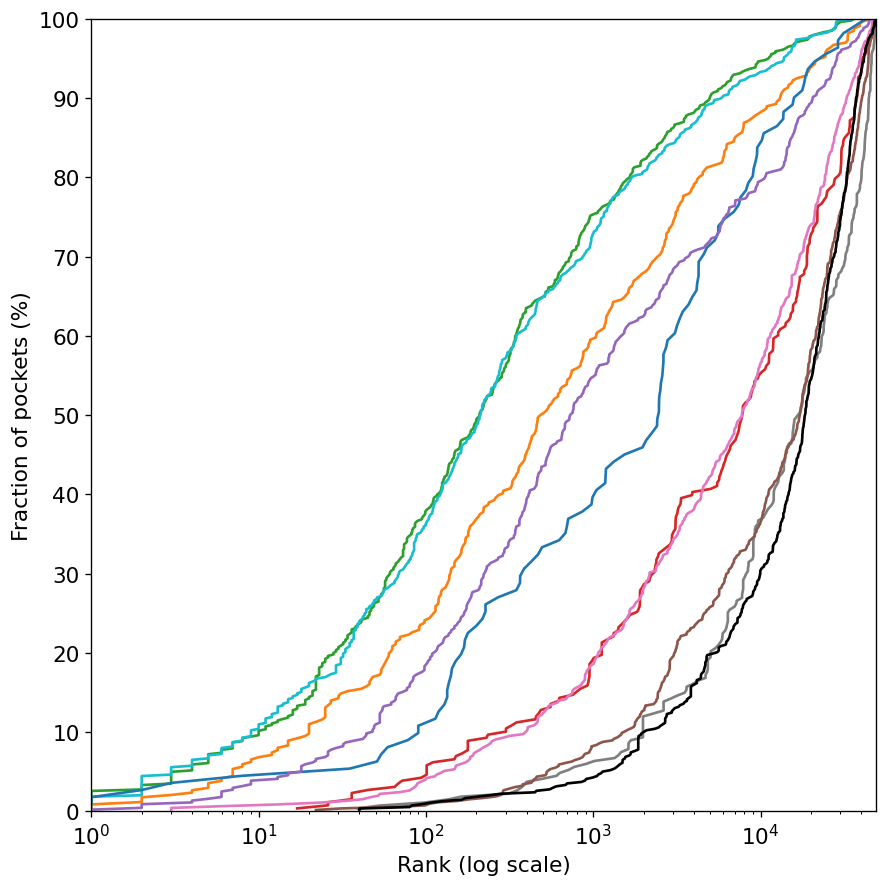

In [63]:
rank_max = N_CCD

fig, ax = plt.subplots(figsize=(7.5, 7.5))
for cond in COND_IDS:
    df = pooled[cond]
    ev = df[get_level_mask(df, PLOT_LEVEL) & df['valid'] & df['in_library']]
    ranks = np.sort(ev['gt_rank'].dropna().astype(int).to_numpy())
    if len(ranks) == 0:
        continue
    cdf = 100 * np.arange(1, len(ranks) + 1) / len(ranks)
    ax.plot(ranks, cdf, lw=1.6, color=COND_COLOUR[cond],
            label=f'{COND_LABEL[cond]} (n={len(ranks):,})')

ax.set_xscale('log'); ax.set_xlim(1, rank_max); ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_xlabel('Rank (log scale)'); ax.set_ylabel('Fraction of pockets (%)')
if SHOW_TITLES_LEGENDS:
    ax.set_title(f'Pooled, de-duplicated, {PLOT_LEVEL} — ground-truth rank ECDF')
    ax.legend(fontsize=7, loc='upper left')
fig.tight_layout()
fig.savefig(BENCH / 'fig52_rank_ecdf_pooled.png', dpi=600, bbox_inches='tight')
plt.show()

## Plots 4 & 5 — how the curves degrade down the whole ladder, every condition

Plots 2/3 froze the ladder at one level (`L3<25`) to get one clean curve per condition. Here it's the opposite trade: **one panel per condition**, and *every* rung of the 13-level funnel drawn as its own curve inside that panel (dark = lenient/`L0`, light = strict/`L4<0.3` — same convention nb44 uses for its threshold sweeps). Same nested funnel as plot 1 (`L0 ⊇ L1 ⊇ L2<0.7 ⊇ ... ⊇ L4<0.3`), not the disjoint per-stratum view — so within one panel, each lighter curve's population is a *subset* of every darker curve's population in that same panel. Thin curves at the light end (see the shrinkage table) are genuinely noisy, especially for `apo_ccd` — that raggedness is real signal about sample size, not a plotting artefact.

In [14]:
LEVEL_CMAP  = plt.colormaps.get_cmap('viridis')
LEVEL_COLOR = {lv: LEVEL_CMAP(i / (len(DE_LEVELS) - 1))
               for i, lv in enumerate(DE_LEVELS)}


def _level_colorbar(fig, axes):
    sm = plt.cm.ScalarMappable(cmap=LEVEL_CMAP, norm=plt.Normalize(0, len(DE_LEVELS) - 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.01, ticks=range(len(DE_LEVELS)))
    cbar.ax.set_yticklabels(DE_LEVELS_FMT, fontsize=8)
    cbar.set_label('De-leakage level  (dark = lenient, light = strict)', fontsize=9)

### Plot 4 — score-threshold survival, all levels × all conditions

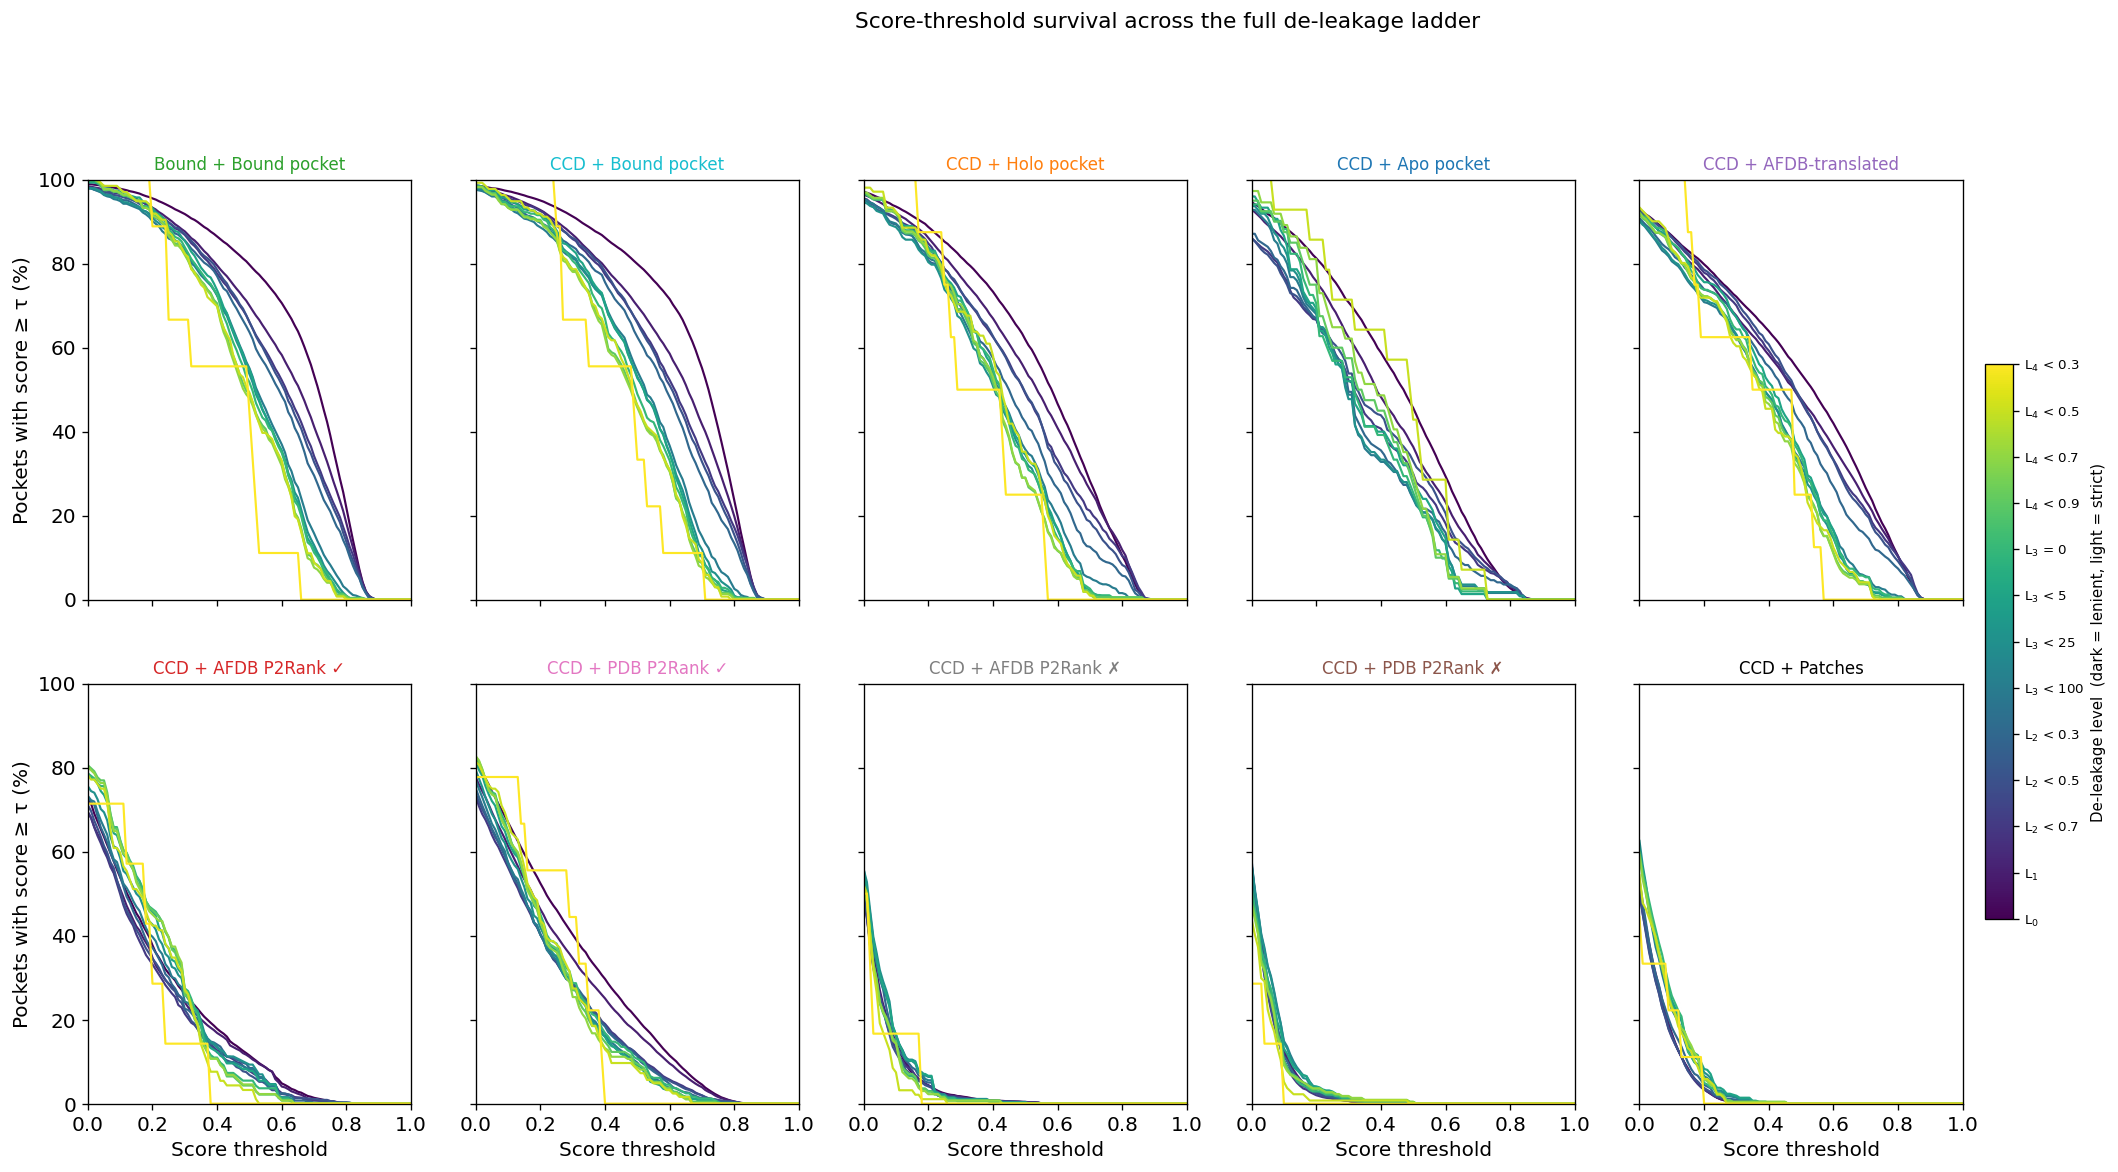

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharex=True, sharey=True)
for ax, cond in zip(axes.flat, COND_IDS):
    df = pooled[cond]
    for lv in DE_LEVELS:
        ev = df[get_level_mask(df, lv) & df['valid'] & df['in_library']]
        vals = ev['gt_score'].dropna().to_numpy(dtype=float)
        if len(vals) < 5:
            continue
        surv = np.array([(vals >= t).mean() * 100 for t in thresholds])
        ax.plot(thresholds, surv, color=LEVEL_COLOR[lv], lw=1.3)
    ax.set_title(COND_LABEL[cond], fontsize=10, color=COND_COLOUR[cond])
    ax.set_xlim(0, 1); ax.set_ylim(0, 100)
for ax in axes[:, 0]:
    ax.set_ylabel('Pockets with score ≥ τ (%)')
for ax in axes[-1, :]:
    ax.set_xlabel('Score threshold')
_level_colorbar(fig, axes)
fig.suptitle('Score-threshold survival across the full de-leakage ladder', y=1.02, fontsize=13)
fig.savefig(BENCH / 'fig52_score_survival_ladder_panel.png', dpi=600, bbox_inches='tight')
plt.show()

### Plot 5 — ground-truth rank ECDF, all levels × all conditions

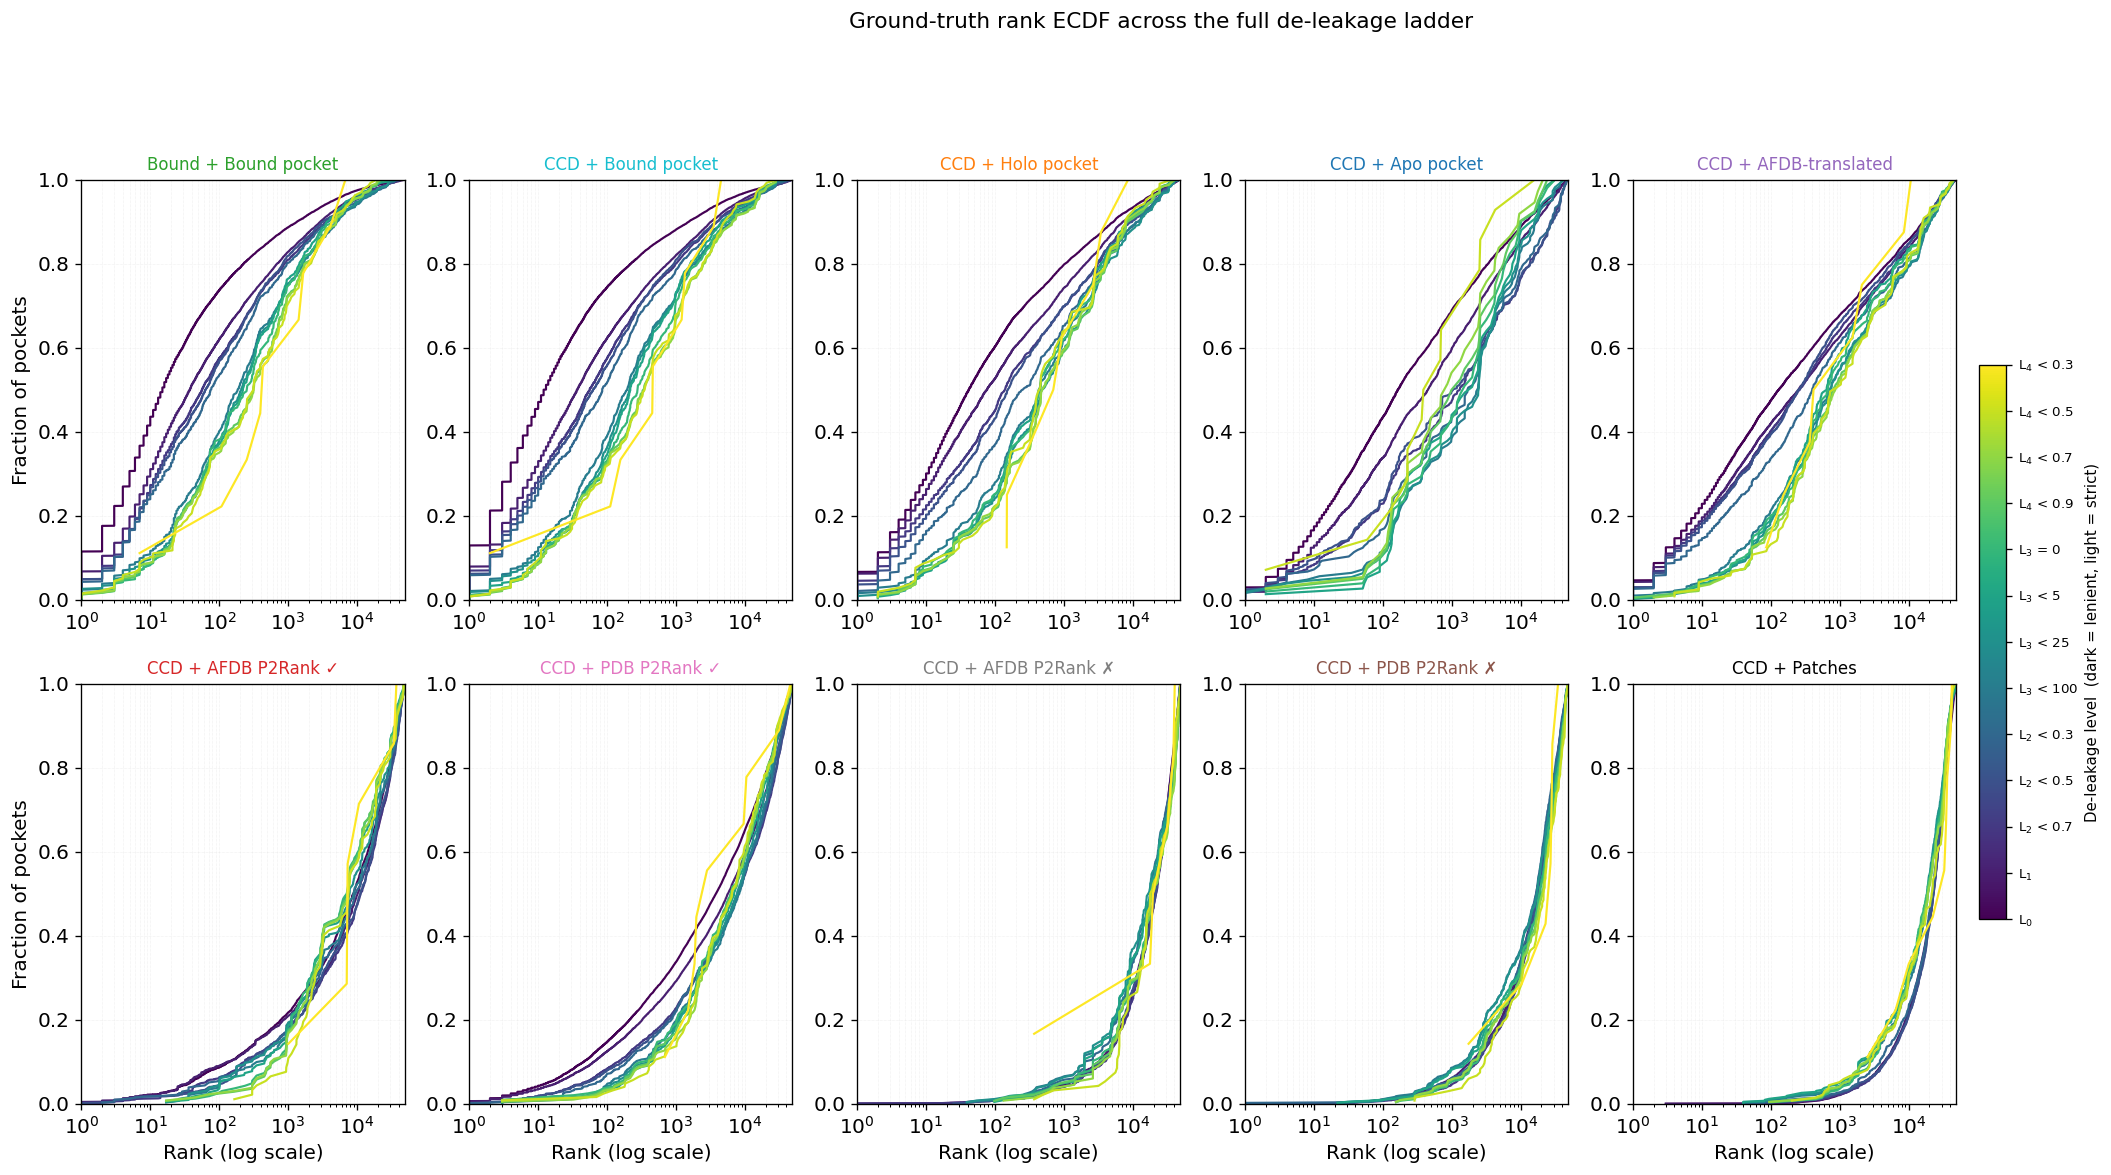

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
for ax, cond in zip(axes.flat, COND_IDS):
    df = pooled[cond]
    for lv in DE_LEVELS:
        ev = df[get_level_mask(df, lv) & df['valid'] & df['in_library']]
        ranks = np.sort(ev['gt_rank'].dropna().astype(int).to_numpy())
        if len(ranks) < 5:
            continue
        cdf = np.arange(1, len(ranks) + 1) / len(ranks)
        ax.plot(ranks, cdf, color=LEVEL_COLOR[lv], lw=1.3)
    ax.set_xscale('log'); ax.set_xlim(1, N_CCD); ax.set_ylim(0, 1)
    ax.set_title(COND_LABEL[cond], fontsize=10, color=COND_COLOUR[cond])
    ax.grid(True, which='both', ls=':', lw=0.3, alpha=0.4)
for ax in axes[:, 0]:
    ax.set_ylabel('Fraction of pockets')
for ax in axes[-1, :]:
    ax.set_xlabel('Rank (log scale)')
_level_colorbar(fig, axes)
fig.suptitle('Ground-truth rank ECDF across the full de-leakage ladder', y=1.02, fontsize=13)
fig.savefig(BENCH / 'fig52_rank_ecdf_ladder_panel.png', dpi=600, bbox_inches='tight')
plt.show()

---
## Notes

* **Key files written to `RESULTS/benchmark/`:** `{ds}_bound_bound_screen.parquet` (new cache, one per dataset), `fig52_ef1pct_vs_deleak_pooled.png`, `fig52_score_survival_pooled.png`, `fig52_rank_ecdf_pooled.png`, `fig52_score_survival_ladder_panel.png`, `fig52_rank_ecdf_ladder_panel.png`.
* `PLOT_LEVEL` is a knob, not a law — re-run plots 2/3 with e.g. `PLOT_LEVEL = 'L2<0.3'` to see the stricter cut; the shrinkage table above shows exactly what gets traded away for it. Plots 4/5 show every level at once, so they don't depend on `PLOT_LEVEL` at all.
* All 10 conditions share the same CCD-sized background now, so every plot's random baseline and rank scale applies uniformly — no per-condition caveats left.